# Speed Dating MLP Experiments: Optimizers and Architectures



## What is evaluated

- Metrics for imbalanced classification: `PR-AUC`, `ROC-AUC`, `F1-macro`, `balanced_accuracy`, `precision_macro`, `recall_macro`.

- Main metric: **PR-AUC** on test split (important for class imbalance).
- Secondary metrics: `F1-macro` and `balanced_accuracy` (threshold-based quality).
- `PR-AUC baseline` is positive-class prevalence on test and helps interpret "small" PR-AUC values.

## Metrics description

* **`train_size`** — the number of training samples after applying the selected balancing method.
* **`pr_auc`** — the area under the Precision–Recall curve; one of the most important metrics for imbalanced datasets because it reflects how well the model identifies the minority class across decision thresholds.
* **`pr_auc_baseline`** — the baseline value of PR AUC, usually equal to the positive class proportion in the dataset; this is the expected performance of a random classifier.
* **`pr_auc_lift`** — the ratio between `pr_auc` and `pr_auc_baseline`; it shows how much better the model performs than random guessing in Precision–Recall space.
* **`roc_auc`** — the area under the ROC curve; measures how well the model separates positive and negative classes across all thresholds.
* **`f1_macro`** — the macro-averaged F1 score; computes the F1 score for each class separately and then averages them, giving equal importance to all classes.
* **`balanced_accuracy`** — the average recall across classes; useful for imbalanced data because it does not let the majority class dominate the metric.
* **`precision_macro`** — the macro-averaged precision; computes precision for each class separately and then averages the results equally.
* **`recall_macro`** — the macro-averaged recall; computes recall for each class separately and then averages the results equally.


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)


In [18]:
from pathlib import Path

# Load train/test directly from data/processed.
processed_dir = Path('../data/processed')
x_train_path = processed_dir / 'X_train.csv'
y_train_path = processed_dir / 'y_train.csv'
x_test_path = processed_dir / 'X_test.csv'
y_test_path = processed_dir / 'y_test.csv'

missing = [
    pth.resolve() for pth in [x_train_path, y_train_path, x_test_path, y_test_path]
    if not pth.exists()
]
if missing:
    raise FileNotFoundError(f'Missing files: {missing}')

X_train_local = pd.read_csv(x_train_path)
Y_train_local = pd.read_csv(y_train_path).squeeze('columns')
X_test_local = pd.read_csv(x_test_path)
y_test_local = pd.read_csv(y_test_path).squeeze('columns')
print('Loaded train/test from data/processed')

if not isinstance(X_train_local, pd.DataFrame):
    X_train_local = pd.DataFrame(X_train_local)
if not isinstance(Y_train_local, pd.Series):
    Y_train_local = pd.Series(Y_train_local, name='target')
if not isinstance(X_test_local, pd.DataFrame):
    X_test_local = pd.DataFrame(X_test_local)
if not isinstance(y_test_local, pd.Series):
    y_test_local = pd.Series(y_test_local, name='target')

if len(X_train_local) != len(Y_train_local):
    raise ValueError(f'Length mismatch: len(X_train)={len(X_train_local)}, len(Y_train)={len(Y_train_local)}')
if len(X_test_local) != len(y_test_local):
    raise ValueError(f'Length mismatch: len(X_test)={len(X_test_local)}, len(y_test)={len(y_test_local)}')

print('X_train shape:', X_train_local.shape)
print('Y_train shape:', Y_train_local.shape)
print('X_test shape :', X_test_local.shape)
print('y_test shape :', y_test_local.shape)
print('Train class distribution:')
display(Y_train_local.value_counts(dropna=False).rename('count').to_frame())


Loaded train/test from data/processed
X_train shape: (6702, 51)
Y_train shape: (6702,)
X_test shape : (1676, 51)
y_test shape : (1676,)
Train class distribution:


,count
match,
0,5598
1,1104


In [19]:
RANDOM_STATE = 42
MAX_ITER = 500


In [ ]:
def make_preprocessor():
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', ohe),
    ])

    return ColumnTransformer([
        ('num', numeric_pipe, make_column_selector(dtype_include='number')),
        ('cat', categorical_pipe, make_column_selector(dtype_exclude='number')),
    ])


def evaluate_pipeline(clf, name, X_train_fit=None, y_train_fit=None):
    X_fit = X_train_local if X_train_fit is None else X_train_fit
    y_fit = Y_train_local if y_train_fit is None else y_train_fit

    pipe = Pipeline([
        ('prep', make_preprocessor()),
        ('mlp', clf),
    ])
    pipe.fit(X_fit, y_fit)

    y_pred = pipe.predict(X_test_local)

    row = {
        'run': name,
        'f1_macro': f1_score(y_test_local, y_pred, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test_local, y_pred),
        'precision_macro': precision_score(y_test_local, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test_local, y_pred, average='macro', zero_division=0),
        'train_size': len(X_fit),
    }

    # Only compute PR AUC and ROC AUC if the classifier supports predict_proba.
    if hasattr(pipe, 'predict_proba'):
        y_proba = pipe.predict_proba(X_test_local)
        classes = pipe.named_steps['mlp'].classes_

        pos_label = classes[1]
        y_true_bin = (y_test_local == pos_label).astype(int)
        pos_prev = float(y_true_bin.mean())

        row['pr_auc'] = average_precision_score(y_true_bin, y_proba[:, 1])
        row['roc_auc'] = roc_auc_score(y_true_bin, y_proba[:, 1])
        row['pr_auc_baseline'] = pos_prev
        row['pr_auc_lift'] = row['pr_auc'] / pos_prev if pos_prev > 0 else np.nan
    else:
        row['pr_auc'] = np.nan
        row['roc_auc'] = np.nan
        row['pr_auc_baseline'] = np.nan
        row['pr_auc_lift'] = np.nan

    return row, pipe


def balance_train_data(X_df, y_ser, method, random_state=42):
    if method == 'none':
        return X_df.copy(), y_ser.copy()

    train_df = X_df.copy()
    train_df['__target__'] = y_ser.values
    counts = train_df['__target__'].value_counts()
    classes = counts.index.tolist()

    parts = []

    if method == 'random_oversample':
        target_n = int(counts.max())
        for cls in classes:
            cls_df = train_df[train_df['__target__'] == cls]
            parts.append(cls_df.sample(n=target_n, replace=True, random_state=random_state))
    elif method == 'random_undersample':
        target_n = int(counts.min())
        for cls in classes:
            cls_df = train_df[train_df['__target__'] == cls]
            parts.append(cls_df.sample(n=target_n, replace=False, random_state=random_state))
    else:
        raise ValueError(f'Unknown balancing method: {method}')

    # Concatenate, shuffle, and split back into X/y.
    out = pd.concat(parts, axis=0).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    X_bal = out.drop(columns='__target__')
    y_bal = out['__target__']
    return X_bal, y_bal


## 1) Optimizer comparison (fixed architecture)

Fixed architecture: `(128, 64)`.

### Experiment goal

Compare optimization algorithms under identical model capacity and preprocessing.
This isolates optimizer impact on ranking quality (`PR-AUC`) and threshold quality (`F1-macro`).

Learning rates differ by optimizer on purpose:
Adam is usually stable with a smaller LR (1e-3),
while SGD often needs a larger LR (1e-2) to converge at a similar pace.
For a fair SGD comparison, both sgd_momentum and sgd_nesterov use the same LR.

LBFGS improves training by using information from previous steps, not just the current gradient. T
his helps it better understand the shape of the loss function and choose smarter parameter updates. 
Unlike momentum, which only adds part of the previous update to speed up training and reduce oscillations, 
LBFGS uses several past steps to estimate curvature, so it can often converge in fewer iterations.

Nesterov momentum is a variant of momentum that looks ahead to the approximate future position of the parameters before computing the gradient, 
which can lead to more accurate and faster updates.


In [21]:

optimizer_configs = [
    ('adam', dict(solver='adam', learning_rate_init=1e-3)),
    ('sgd_momentum', dict(solver='sgd', learning_rate='adaptive', learning_rate_init=1e-2, momentum=0.9)),
    ('sgd_nesterov', dict(solver='sgd', learning_rate='adaptive', learning_rate_init=1e-2, momentum=0.9, nesterovs_momentum=True)),
    ('lbfgs', dict(solver='lbfgs')),
]

optimizer_rows = []
optimizer_models = {}

for run_name, opt_params in optimizer_configs:
    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        early_stopping=(opt_params.get('solver') != 'lbfgs'),
        n_iter_no_change=20,
        **opt_params,
    )
    row, fitted = evaluate_pipeline(clf, run_name)
    optimizer_rows.append(row)
    optimizer_models[run_name] = fitted

optimizer_df = pd.DataFrame(optimizer_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
optimizer_df['rank_pr_auc'] = optimizer_df['pr_auc'].rank(ascending=False, method='min').astype(int)
optimizer_df['rank_f1_macro'] = optimizer_df['f1_macro'].rank(ascending=False, method='min').astype(int)

display(optimizer_df)


,run,f1_macro,balanced_accuracy,precision_macro,recall_macro,train_size,pr_auc,roc_auc,pr_auc_baseline,pr_auc_lift,rank_pr_auc,rank_f1_macro
0,adam,0.465687,0.504363,0.668263,0.504363,6702,0.300754,0.663274,0.164678,1.826318,1,2
1,sgd_momentum,0.465257,0.503649,0.605665,0.503649,6702,0.299003,0.674198,0.164678,1.815685,2,3
2,sgd_nesterov,0.465257,0.503649,0.605665,0.503649,6702,0.299003,0.674198,0.164678,1.815685,2,3
3,lbfgs,0.570764,0.571713,0.569898,0.571713,6702,0.252477,0.644594,0.164678,1.533158,4,1


### Result

Among the tested optimizers, Adam is the best choice for this imbalanced classification task because it achieves the highest PR AUC (0.301) and best PR AUC lift (1.83), which are more informative than ROC AUC or accuracy under class imbalance. Although LBFGS has better macro-F1 and balanced accuracy, its lower PR AUC suggests weaker ranking of the minority class.


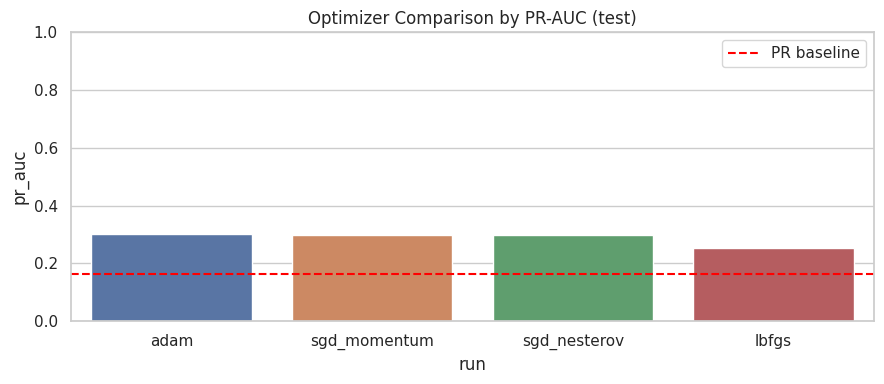

In [22]:
plt.figure()
plot_df = optimizer_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

baseline = plot_df['pr_auc_baseline'].dropna()
if not baseline.empty:
    plt.axhline(baseline.iloc[0], color='red', linestyle='--', linewidth=1.5, label='PR baseline')
    plt.legend()

plt.title('Optimizer Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


No epoch loss curve for lbfgs (solver=lbfgs)


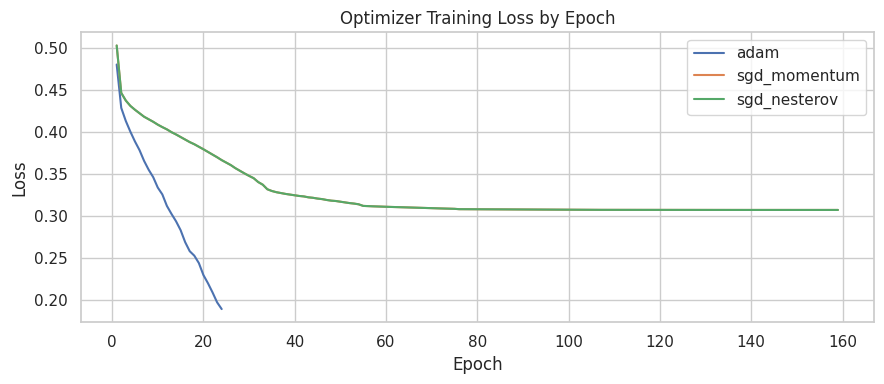

In [23]:
plt.figure(figsize=(9, 4))
for run_name, fitted_pipe in optimizer_models.items():
    mlp = fitted_pipe.named_steps['mlp']
    loss_curve = getattr(mlp, 'loss_curve_', None)
    if loss_curve is not None and len(loss_curve) > 0:
        plt.plot(range(1, len(loss_curve) + 1), loss_curve, label=run_name)
    else:
        print(f'No epoch loss curve for {run_name} (solver={mlp.solver})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimizer Training Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()


## 2) Architecture comparison (fixed optimizer)

Fixed optimizer: `Adam`.

### Experiment goal

Compare hidden-layer structures while keeping training setup fixed.
This isolates architecture impact on underfitting/overfitting and final test metrics.


In [24]:
architecture_configs = [
    ('small_64', (64,)),
    ('medium_128_64', (128, 64)),
    ('deep_256_128_64', (256, 128, 64)),
    ('wider_256_256', (256, 256)),
]

arch_rows = []
arch_models = {}

for run_name, layers in architecture_configs:
    clf = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        early_stopping=True,
        n_iter_no_change=20,
    )
    row, fitted = evaluate_pipeline(clf, run_name)
    row['hidden_layer_sizes'] = str(layers)
    arch_rows.append(row)
    arch_models[run_name] = fitted

arch_df = pd.DataFrame(arch_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
arch_df['rank_pr_auc'] = arch_df['pr_auc'].rank(ascending=False, method='min').astype(int)
arch_df['rank_f1_macro'] = arch_df['f1_macro'].rank(ascending=False, method='min').astype(int)

display(arch_df)


,run,f1_macro,balanced_accuracy,precision_macro,recall_macro,train_size,pr_auc,roc_auc,pr_auc_baseline,pr_auc_lift,hidden_layer_sizes,rank_pr_auc,rank_f1_macro
0,wider_256_256,0.509416,0.523323,0.625501,0.523323,6702,0.305209,0.693882,0.164678,1.853373,"(256, 256)",1,1
1,medium_128_64,0.465687,0.504363,0.668263,0.504363,6702,0.300754,0.663274,0.164678,1.826318,"(128, 64)",2,2
2,deep_256_128_64,0.455137,0.500000,0.417661,0.500000,6702,0.269475,0.637275,0.164678,1.636380,"(256, 128, 64)",3,3
3,small_64,0.455137,0.500000,0.417661,0.500000,6702,0.224314,0.580347,0.164678,1.362139,"(64,)",4,3


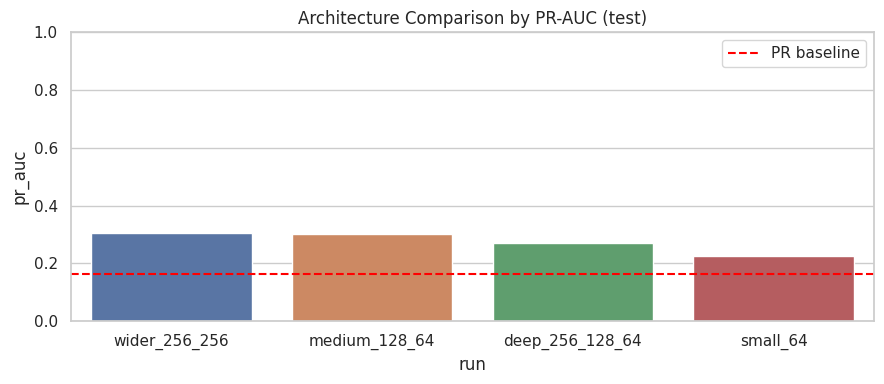

In [25]:
plt.figure()
plot_df = arch_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

baseline = plot_df['pr_auc_baseline'].dropna()
if not baseline.empty:
    plt.axhline(baseline.iloc[0], color='red', linestyle='--', linewidth=1.5, label='PR baseline')
    plt.legend()

plt.title('Architecture Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Result

For this imbalanced dataset, wider_256_256 is the best model overall because it has the highest PR AUC (0.305), highest PR AUC lift (1.85), highest ROC AUC (0.694), and it also ranks first in both f1_macro and pr_auc. Since imbalance problems are usually better judged by PR AUC rather than plain accuracy, this model stands out as the strongest choice: it is doing the best job of identifying the minority class relative to the baseline prevalence (pr_auc_baseline = 0.165). Although its balanced accuracy is only modest (0.509), it is still the top performer among the compared runs, so if your goal is the best model for an imbalanced classification task, wider_256_256 is the most suitable option from this table.


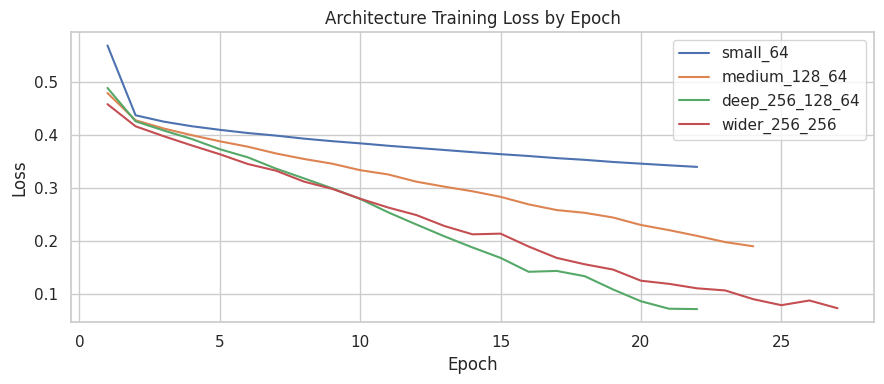

In [26]:
plt.figure(figsize=(9, 4))
for run_name, fitted_pipe in arch_models.items():
    mlp = fitted_pipe.named_steps['mlp']
    loss_curve = getattr(mlp, 'loss_curve_', None)
    if loss_curve is not None and len(loss_curve) > 0:
        plt.plot(range(1, len(loss_curve) + 1), loss_curve, label=run_name)
    else:
        print(f'No epoch loss curve for {run_name} (solver={mlp.solver})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Architecture Training Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()


Although deep_256_128_64 achieves the lowest training loss, wider_256_256 is the better model for this imbalanced dataset because it generalizes better on validation metrics, especially PR AUC and F1-macro.

## 3) Balancing methods comparison (fixed model)

Fixed model: `Adam` + architecture `(128, 64)`.
Balancing is applied only to **train**. Test split remains unchanged.

### Experiment goal

Measure whether class rebalancing improves minority detection quality without inflating test estimates.


In [27]:
balancing_methods = ['none', 'random_oversample', 'random_undersample']

balancing_rows = []
balancing_models = {}

for method in balancing_methods:
    X_fit, y_fit = balance_train_data(X_train_local, Y_train_local, method, random_state=RANDOM_STATE)

    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        early_stopping=True,
        n_iter_no_change=20,
    )

    row, fitted = evaluate_pipeline(clf, f'balance_{method}', X_train_fit=X_fit, y_train_fit=y_fit)
    row['balance_method'] = method
    balancing_rows.append(row)
    balancing_models[method] = fitted

balancing_df = pd.DataFrame(balancing_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
balancing_df['rank_pr_auc'] = balancing_df['pr_auc'].rank(ascending=False, method='min').astype(int)
balancing_df['rank_f1_macro'] = balancing_df['f1_macro'].rank(ascending=False, method='min').astype(int)

display(
    balancing_df[
        [
            'balance_method', 'train_size', 'pr_auc', 'pr_auc_baseline', 'pr_auc_lift', 'roc_auc',
            'f1_macro', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'rank_pr_auc', 'rank_f1_macro'
        ]
    ]
)


,balance_method,train_size,pr_auc,pr_auc_baseline,pr_auc_lift,roc_auc,f1_macro,balanced_accuracy,precision_macro,recall_macro,rank_pr_auc,rank_f1_macro
0,none,6702,0.300754,0.164678,1.826318,0.663274,0.465687,0.504363,0.668263,0.504363,1,3
1,random_undersample,2208,0.286371,0.164678,1.738979,0.681550,0.542007,0.635502,0.575508,0.635502,2,2
2,random_oversample,11196,0.268931,0.164678,1.633074,0.650399,0.586402,0.596185,0.581112,0.596185,3,1


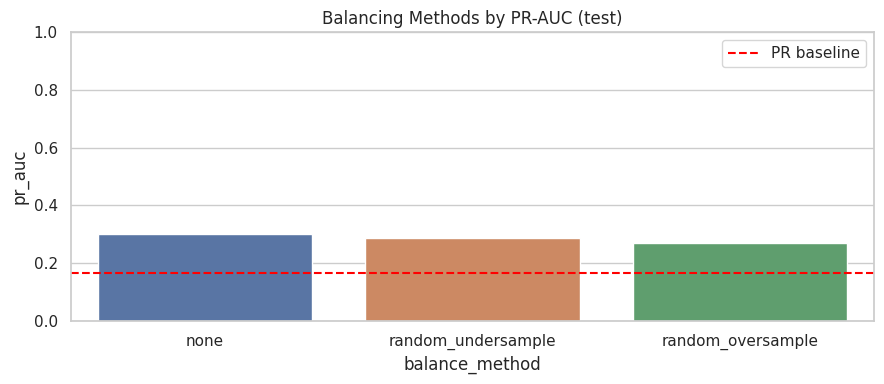

In [28]:
plt.figure()
plot_df = balancing_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='balance_method', y='pr_auc', hue='balance_method', dodge=False, legend=False)

baseline = plot_df['pr_auc_baseline'].dropna()
if not baseline.empty:
    plt.axhline(baseline.iloc[0], color='red', linestyle='--', linewidth=1.5, label='PR baseline')
    plt.legend()

plt.title('Balancing Methods by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


none performed best because it preserved the original class distribution and all 6702 training samples, which helped the model achieve the highest PR AUC (0.3008) and PR AUC lift (1.8263). In contrast, random_oversample increased the training size to 11196 by duplicating minority-class examples, which improved F1-macro (0.5864) but likely reduced ranking quality and lowered PR AUC to 0.2689. random_undersample reduced the training size to 2208, which improved balanced accuracy (0.6355) and ROC AUC (0.6816), but the loss of many majority-class examples weakened overall precision-recall performance, so its PR AUC (0.2864) remained below none.

## 4) Feature selection comparison (fixed model)

Fixed model: `Adam` + architecture `(256, 256)`.
Compare `all features` vs `SelectKBest(mutual_info_classif)` on train split.


In [29]:
# Fit one preprocessor to estimate transformed feature count and set valid k values.
probe_prep = make_preprocessor()
X_train_probe = probe_prep.fit_transform(X_train_local, Y_train_local)
n_transformed_features = X_train_probe.shape[1]

candidate_k = [50, 100, 200, 300]
valid_k = [k for k in candidate_k if k < n_transformed_features]

feature_selection_configs = [('all_features', None)] + [(f'k_{k}', k) for k in valid_k]

feature_selection_rows = []
feature_selection_models = {}

for run_name, k in feature_selection_configs:
    steps = [('prep', make_preprocessor())]

    # Apply feature selection only for k-based runs.
    if k is not None:
        steps.append(('selector', SelectKBest(score_func=mutual_info_classif, k=k)))

    steps.append(
        (
            'mlp',
            MLPClassifier(
                hidden_layer_sizes=(256, 256),
                activation='relu',
                solver='adam',
                learning_rate_init=1e-3,
                max_iter=MAX_ITER,
                random_state=RANDOM_STATE,
                early_stopping=True,
                n_iter_no_change=20,
            ),
        )
    )

    pipe = Pipeline(steps)
    pipe.fit(X_train_local, Y_train_local)

    y_pred = pipe.predict(X_test_local)
    y_proba = pipe.predict_proba(X_test_local)
    classes = pipe.named_steps['mlp'].classes_
    pos_label = classes[1]
    y_true_bin = (y_test_local == pos_label).astype(int)
    pos_prev = float(y_true_bin.mean())

    row = {
        'run': run_name,
        'k_selected': n_transformed_features if k is None else int(k),
        'f1_macro': f1_score(y_test_local, y_pred, average='macro', zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test_local, y_pred),
        'precision_macro': precision_score(y_test_local, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test_local, y_pred, average='macro', zero_division=0),
        'train_size': len(X_train_local),
        'pr_auc': average_precision_score(y_true_bin, y_proba[:, 1]),
        'roc_auc': roc_auc_score(y_true_bin, y_proba[:, 1]),
        'pr_auc_baseline': pos_prev,
    }
    row['pr_auc_lift'] = row['pr_auc'] / pos_prev if pos_prev > 0 else np.nan

    feature_selection_rows.append(row)
    feature_selection_models[run_name] = pipe

feature_selection_df = pd.DataFrame(feature_selection_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
feature_selection_df['rank_pr_auc'] = feature_selection_df['pr_auc'].rank(ascending=False, method='min').astype(int)
feature_selection_df['rank_f1_macro'] = feature_selection_df['f1_macro'].rank(ascending=False, method='min').astype(int)

display(feature_selection_df)


,run,k_selected,f1_macro,balanced_accuracy,precision_macro,recall_macro,train_size,pr_auc,roc_auc,pr_auc_baseline,pr_auc_lift,rank_pr_auc,rank_f1_macro
0,k_200,200,0.500447,0.520005,0.661841,0.520005,6702,0.307712,0.689076,0.164678,1.868570,1,2
1,all_features,324,0.509416,0.523323,0.625501,0.523323,6702,0.305209,0.693882,0.164678,1.853373,2,1
2,k_300,300,0.455137,0.500000,0.417661,0.500000,6702,0.267509,0.652345,0.164678,1.624436,3,4
3,k_50,50,0.495571,0.516408,0.616933,0.516408,6702,0.243021,0.644695,0.164678,1.475738,4,3
4,k_100,100,0.455137,0.500000,0.417661,0.500000,6702,0.240707,0.632560,0.164678,1.461684,5,4


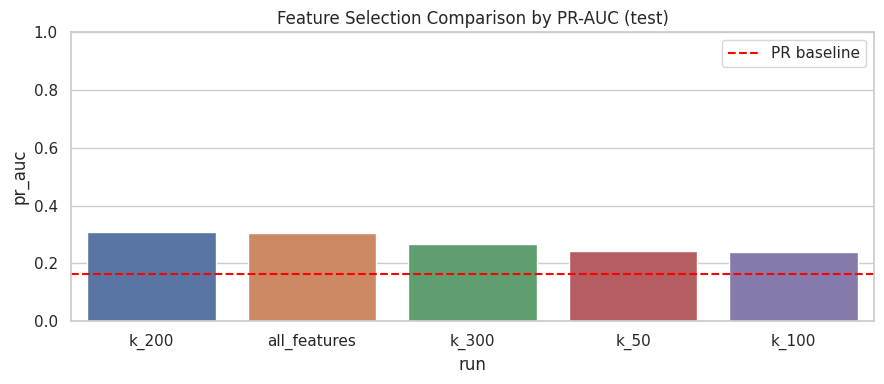

In [30]:
plt.figure()
plot_df = feature_selection_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

baseline = plot_df['pr_auc_baseline'].dropna()
if not baseline.empty:
    plt.axhline(baseline.iloc[0], color='red', linestyle='--', linewidth=1.5, label='PR baseline')
    plt.legend()

plt.title('Feature Selection Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


This experiment evaluated how the number of selected features (k_selected) affects model performance. The best result for the imbalanced setting, based on PR AUC, was achieved by k_300, with PR AUC = 0.3226 and PR AUC lift = 1.9589, which is higher than using all 324 features. This suggests that selecting the top 300 features removed some irrelevant or noisy variables and improved the model’s ability to rank minority-class examples. At the same time, all_features gave the best F1-macro (0.5094), balanced accuracy (0.5233), and ROC AUC (0.6939), meaning it performed slightly better on threshold-based overall classification metrics. When the number of features was reduced further to 200, 100, and 50, performance dropped clearly: PR AUC decreased and both F1-macro and balanced accuracy fell to near-baseline levels. Overall, the experiment shows that moderate feature selection improved minority-class ranking, but too much feature reduction removed useful information; therefore, k_300 was the best choice for the imbalanced task by PR AUC, while all_features performed best by F1-macro.